# Delivery Delay & Operations Analytics

**Objective:** Measure delivery performance, identify operational bottlenecks, and estimate late-delivery risk.

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Delay definition:** `delay_days = actual delivery date - estimated delivery date` (positive = late).

## 1. Setup and Data Loading

Upload `olist_orders_dataset.csv`, `olist_order_items_dataset.csv`, `olist_products_dataset.csv`, `olist_sellers_dataset.csv` and `olist_customers_dataset.csv` to the Colab session.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 2. Data Preparation

In [3]:
# Convert date columns
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                'order_delivered_customer_date', 'order_estimated_delivery_date']
for column in date_columns:
    orders[column] = pd.to_datetime(orders[column], errors='coerce')

# Keep delivered orders that have both a delivery date and an estimated date
delivered_orders = orders[
    (orders['order_status'] == 'delivered') &
    orders['order_delivered_customer_date'].notna() &
    orders['order_estimated_delivery_date'].notna()
].copy()

delivered_orders.shape

(96470, 8)

In [4]:
# Calculate delivery delay in days
delivered_orders['delay_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_estimated_delivery_date']
).dt.days

# A delivery is on time when it is delivered on or before the estimated date
delivered_orders['is_late'] = (delivered_orders['delay_days'] > 0).astype(int)
delivered_orders['is_on_time'] = (delivered_orders['delay_days'] <= 0).astype(int)

# Calculate the total order processing/delivery duration
delivered_orders['delivery_days_from_purchase'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
).dt.days

# Add simple calendar fields
delivered_orders['purchase_weekday'] = delivered_orders['order_purchase_timestamp'].dt.day_name()
delivered_orders['purchase_month'] = delivered_orders['order_purchase_timestamp'].dt.month
delivered_orders['purchase_year'] = delivered_orders['order_purchase_timestamp'].dt.year

# Create simple seasons for a beginner-friendly analysis
def get_season(month):
    # Brazil is in the southern hemisphere, so seasons are reversed
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

delivered_orders['season'] = delivered_orders['purchase_month'].apply(get_season)

delivered_orders[['delay_days', 'is_late', 'delivery_days_from_purchase', 'season']].head()

,delay_days,is_late,delivery_days_from_purchase,season
0,-8,0,8,Spring
1,-6,0,13,Winter
2,-18,0,9,Winter
3,-13,0,13,Spring
4,-10,0,2,Summer


## 3. Combine Data Tables

In [5]:
# Summarize item information at order level
items_by_order = order_items.groupby('order_id').agg(
    number_of_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    seller_id=('seller_id', 'first'),
    product_id=('product_id', 'first')
).reset_index()

# Join order items to orders
analysis = delivered_orders.merge(items_by_order, on='order_id', how='left')

# Join customer details
analysis = analysis.merge(
    customers[['customer_id', 'customer_state', 'customer_city']],
    on='customer_id',
    how='left'
)

# Join seller details
analysis = analysis.merge(
    sellers[['seller_id', 'seller_state', 'seller_city']],
    on='seller_id',
    how='left'
)

# Join product category
analysis = analysis.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Fill missing category values so charts do not fail
analysis['product_category_name'] = analysis['product_category_name'].fillna('Unknown')

# Create route and same-state features
analysis['route'] = analysis['seller_state'].fillna('Unknown') + ' to ' + analysis['customer_state'].fillna('Unknown')
analysis['same_state_route'] = (analysis['seller_state'] == analysis['customer_state']).astype(int)

analysis.shape

(96470, 28)

In [6]:
# Check missing values in important columns
important_columns = [
    'delay_days', 'is_late', 'seller_id', 'seller_state',
    'customer_state', 'product_category_name', 'route'
]

missing_summary = analysis[important_columns].isnull().sum().sort_values(ascending=False)
missing_summary

,0
delay_days,0
is_late,0
seller_id,0
seller_state,0
customer_state,0
product_category_name,0
route,0


## 4. Delivery KPIs

In [7]:
late_only = analysis[analysis['is_late'] == 1]

kpis = pd.DataFrame({
    'KPI': ['Delivered orders analysed', 'Late orders', 'On-time %',
            'Average delay vs estimate (days)', 'Median delay vs estimate (days)',
            'Average delay of late orders (days)', 'Average delivery time from purchase (days)'],
    'Value': [len(analysis), int(analysis['is_late'].sum()),
              round(analysis['is_on_time'].mean() * 100, 2),
              round(analysis['delay_days'].mean(), 2), analysis['delay_days'].median(),
              round(late_only['delay_days'].mean(), 2),
              round(analysis['delivery_days_from_purchase'].mean(), 2)]
})
kpis

,KPI,Value
0,Delivered orders analysed,96470.00
1,Late orders,6534.00
2,On-time %,93.23
3,Average delay vs estimate (days),-11.88
4,Median delay vs estimate (days),-12.00
5,Average delay of late orders (days),10.62
6,Average delivery time from purchase (days),12.09


## 5. Delay Distribution

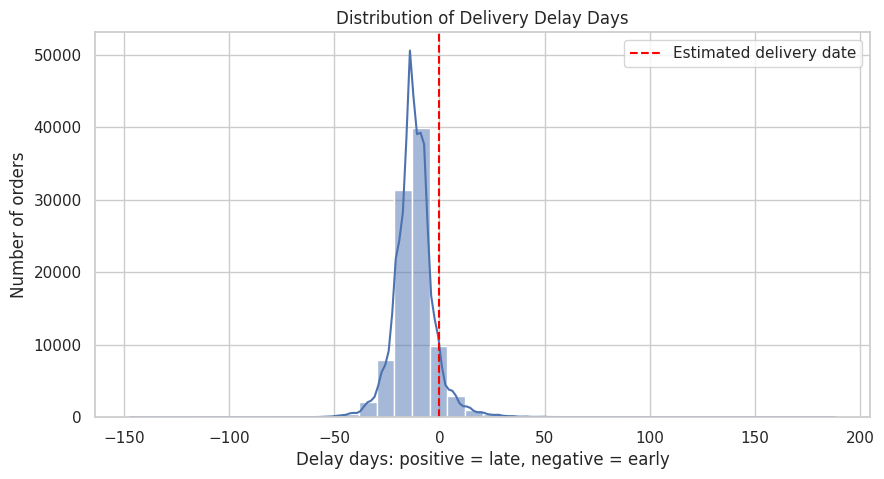

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=analysis, x='delay_days', bins=40, kde=True)
plt.axvline(0, color='red', linestyle='--', label='Estimated delivery date')
plt.title('Distribution of Delivery Delay Days')
plt.xlabel('Delay days: positive = late, negative = early')
plt.ylabel('Number of orders')
plt.legend()
plt.show()

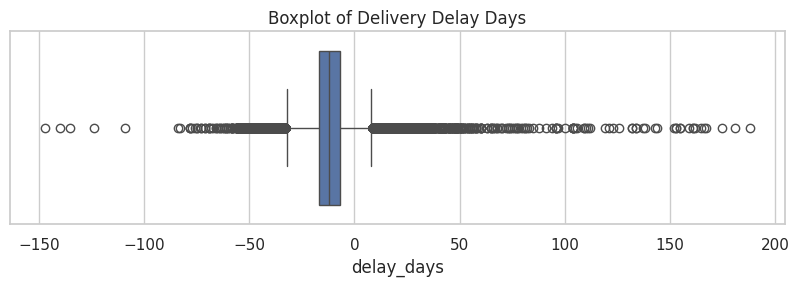

,order_id,delay_days,seller_state,customer_state
53963,1b3190b2dfa9d789e1f14c05b647a14a,188,SP,RJ
19029,ca07593549f1816d26a572e06dc1eab6,181,MG,ES
11074,47b40429ed8cce3aee9199792275433f,175,SP,SP
78961,2fe324febf907e3ea3f2aa9650869fa5,167,RS,SP
86459,285ab9426d6982034523a855f55a885e,166,MG,SE
59778,440d0d17af552815d15a9e41abe49359,165,MG,PA
66712,c27815f7e3dd0b926b58552628481575,162,SP,MG
37371,0f4519c5f1c541ddec9f21b3bddd533a,161,SP,PI
39636,d24e8541128cea179a11a65176e0a96f,161,SP,SP
52862,2d7561026d542c8dbd8f0daeadf67a43,159,SP,SE


In [9]:
# Boxplot to see extreme delays
plt.figure(figsize=(10, 2.5))
sns.boxplot(data=analysis, x='delay_days')
plt.title('Boxplot of Delivery Delay Days')
plt.show()

# Print the most delayed orders
analysis[['order_id', 'delay_days', 'seller_state', 'customer_state']].sort_values(
    by='delay_days', ascending=False
).head(10)

## 6. Delay Segmentation

Seller state is the warehouse proxy; seller state to customer state is the route. Groups below the stated order minimum are excluded.

**Seller hotspots (50+ orders)**

In [10]:
# Helper function: calculate useful metrics by group
def summarize_by_group(data, group_column):
    result = data.groupby(group_column).agg(
        orders=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        on_time_percentage=('is_on_time', 'mean'),
        average_delay_days=('delay_days', 'mean')
    ).reset_index()
    result['on_time_percentage'] = result['on_time_percentage'] * 100
    result['late_percentage'] = result['late_orders'] / result['orders'] * 100
    return result.sort_values('late_percentage', ascending=False)

# Avoid very small groups when finding operational hotspots
def show_reliable_hotspots(data, group_column, minimum_orders=50, top_n=10):
    summary = summarize_by_group(data, group_column)
    summary = summary[summary['orders'] >= minimum_orders]
    return summary.head(top_n)

show_reliable_hotspots(analysis, 'seller_id', minimum_orders=50, top_n=10)

,seller_id,orders,late_orders,on_time_percentage,average_delay_days,late_percentage
994,54965bbe3e4f07ae045b90b0b8541f52,72,22,69.444444,-3.333333,30.555556
2202,beadbee30901a7f61d031b6b686095ad,63,15,76.190476,-9.285714,23.809524
1920,a49928bcdf77c55c6d6e05e09a9b4ca5,94,21,77.659574,-4.244681,22.340426
1329,712e6ed8aa4aa1fa65dab41fed5737e4,77,16,79.220779,-9.116883,20.779221
78,06a2c3af7b3aee5d69171b0e14f0ee87,388,74,80.927835,-11.324742,19.072165
2710,ea566164622c6b439516ab18062c42cd,50,9,82.000000,-8.100000,18.000000
2438,d20b021d3efdf267a402c402a48ea64b,78,14,82.051282,-5.230769,17.948718
1135,6039e27294dc75811c0d8a39069f52c0,62,11,82.258065,-7.048387,17.741935
1599,88460e8ebdecbfecb5f9601833981930,238,42,82.352941,-10.974790,17.647059
2355,cac4c8e7b1ca6252d8f20b2fc1a2e4af,71,12,83.098592,-6.478873,16.901408


**Route hotspots (50+ orders)**

In [11]:
show_reliable_hotspots(analysis, 'route', minimum_orders=50, top_n=10)

,route,orders,late_orders,on_time_percentage,average_delay_days,late_percentage
383,SP to AL,255,61,76.078431,-7.898039,23.921569
283,RJ to CE,54,11,79.629630,-6.425926,20.370370
141,MA to SP,123,25,79.674797,-9.813008,20.325203
391,SP to MA,491,93,81.059063,-9.293279,18.940937
398,SP to PI,329,54,83.586626,-10.531915,16.413374
406,SP to SE,208,34,83.653846,-9.413462,16.346154
152,MG to MA,61,9,85.245902,-10.967213,14.754098
255,PR to BA,143,21,85.314685,-10.251748,14.685315
400,SP to RJ,8158,1152,85.878892,-10.828880,14.121108
256,PR to CE,64,9,85.937500,-9.562500,14.062500


**Warehouse proxy: seller state (100+ orders)**

In [12]:
show_reliable_hotspots(analysis, 'seller_state', minimum_orders=100, top_n=10)

,seller_state,orders,late_orders,on_time_percentage,average_delay_days,late_percentage
6,MA,388,74,80.927835,-11.324742,19.072165
21,SP,68415,5015,92.669736,-11.125294,7.330264
15,RJ,4185,301,92.807646,-12.409319,7.192354
4,ES,308,19,93.831169,-13.064935,6.168831
14,PR,7429,402,94.588774,-14.076861,5.411226
3,DF,803,42,94.769614,-13.297634,5.230386
19,SC,3551,175,95.071811,-14.039144,4.928189
1,BA,549,27,95.081967,-12.615665,4.918033
7,MG,7647,370,95.161501,-13.314502,4.838499
9,MT,134,5,96.268657,-15.626866,3.731343


**Product category hotspots (50+ orders)**

In [13]:
show_reliable_hotspots(analysis, 'product_category_name', minimum_orders=50, top_n=10)

,product_category_name,orders,late_orders,on_time_percentage,average_delay_days,late_percentage
8,audio,344,41,88.081395,-10.011628,11.918605
15,casa_conforto,370,35,90.540541,-9.864865,9.459459
40,fashion_underwear_e_moda_praia,117,11,90.598291,-10.504274,9.401709
50,livros_tecnicos,255,21,91.764706,-11.317647,8.235294
10,bebes,2763,226,91.820485,-11.428520,8.179515
56,moveis_escritorio,1246,101,91.894061,-11.731140,8.105939
7,artigos_de_natal,125,10,92.000000,-12.184000,8.000000
31,eletronicos,2507,192,92.341444,-10.978061,7.658556
58,moveis_sala,409,31,92.420538,-11.660147,7.579462
46,instrumentos_musicais,607,46,92.421746,-11.436573,7.578254


**Weekday and season**

In [14]:
weekday_summary = summarize_by_group(analysis, 'purchase_weekday')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_summary['weekday_number'] = weekday_summary['purchase_weekday'].apply(lambda x: weekday_order.index(x))
weekday_summary.sort_values('weekday_number')

,purchase_weekday,orders,late_orders,on_time_percentage,average_delay_days,late_percentage,weekday_number
1,Monday,15701,1168,92.560983,-11.304949,7.439017,0
5,Tuesday,15502,1093,92.949297,-11.689975,7.050703,1
6,Wednesday,15074,990,93.432400,-11.900159,6.567600,2
4,Thursday,14322,903,93.695015,-12.004608,6.304985,3
0,Friday,13684,960,92.984507,-11.668006,7.015493,4
2,Saturday,10555,696,93.405969,-12.495500,6.594031,5
3,Sunday,11632,724,93.775791,-12.386692,6.224209,6


In [15]:
season_summary = summarize_by_group(analysis, 'season')
season_summary

,season,orders,late_orders,on_time_percentage,average_delay_days,late_percentage
0,Autumn,28944,2450,91.535379,-11.196103,8.464621
2,Summer,21541,1811,91.592777,-12.525092,8.407223
1,Spring,16182,1276,92.114695,-10.466877,7.885305
3,Winter,29803,997,96.654699,-12.831896,3.345301


## 7. Operations Charts

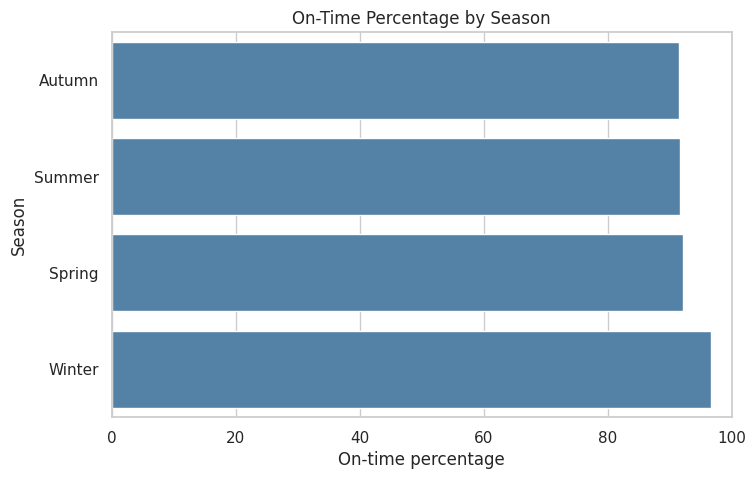

In [16]:
# On-time percentage by season
season_chart = summarize_by_group(analysis, 'season').sort_values('on_time_percentage')

plt.figure(figsize=(8, 5))
sns.barplot(data=season_chart, x='on_time_percentage', y='season', color='steelblue')
plt.xlim(0, 100)
plt.title('On-Time Percentage by Season')
plt.xlabel('On-time percentage')
plt.ylabel('Season')
plt.show()

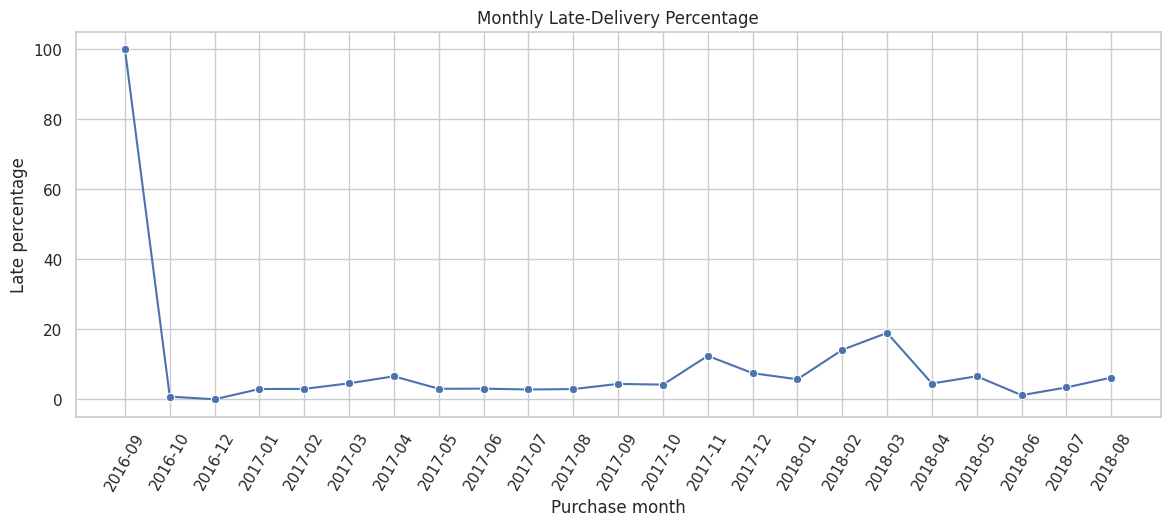

In [17]:
# Monthly trend of late percentage
monthly_summary = analysis.groupby(['purchase_year', 'purchase_month']).agg(
    orders=('order_id', 'count'),
    late_percentage=('is_late', 'mean'),
    average_delay_days=('delay_days', 'mean')
).reset_index()
monthly_summary['late_percentage'] = monthly_summary['late_percentage'] * 100
monthly_summary['year_month'] = (
    monthly_summary['purchase_year'].astype(str) + '-' +
    monthly_summary['purchase_month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_summary, x='year_month', y='late_percentage', marker='o')
plt.xticks(rotation=60)
plt.title('Monthly Late-Delivery Percentage')
plt.xlabel('Purchase month')
plt.ylabel('Late percentage')
plt.show()

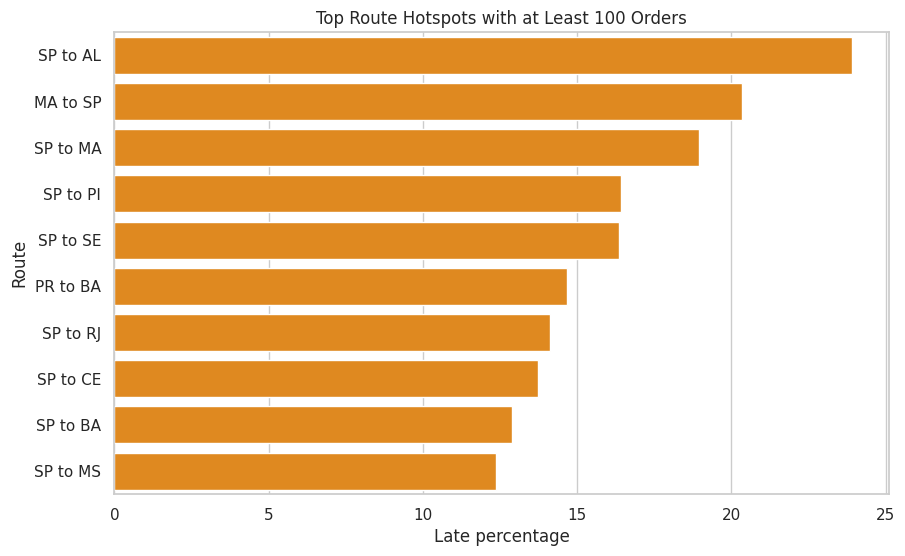

In [18]:
# Top route hotspots by late percentage
route_summary = show_reliable_hotspots(analysis, 'route', minimum_orders=100, top_n=10)

plt.figure(figsize=(10, 6))
sns.barplot(data=route_summary, x='late_percentage', y='route', color='darkorange')
plt.title('Top Route Hotspots with at Least 100 Orders')
plt.xlabel('Late percentage')
plt.ylabel('Route')
plt.show()

**High-delay combinations: seller state x customer state**

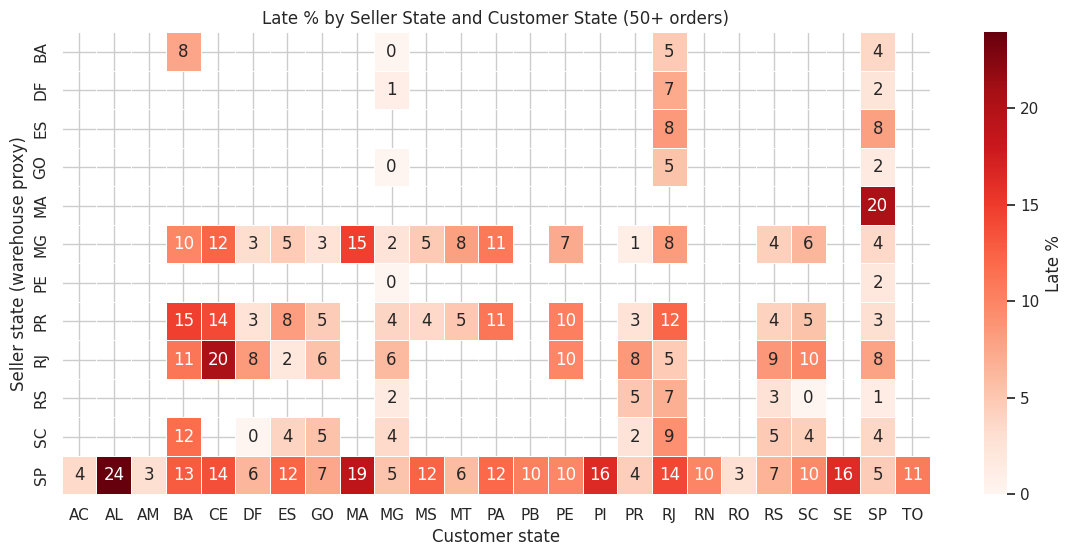

In [19]:
combo = analysis.groupby(['seller_state', 'customer_state']).agg(
    orders=('order_id', 'count'),
    late_percentage=('is_late', 'mean')
).reset_index()
combo['late_percentage'] = combo['late_percentage'] * 100
combo = combo[combo['orders'] >= 50]

heatmap_data = combo.pivot(index='seller_state', columns='customer_state', values='late_percentage')

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': 'Late %'})
plt.title('Late % by Seller State and Customer State (50+ orders)')
plt.xlabel('Customer state')
plt.ylabel('Seller state (warehouse proxy)')
plt.show()

## 8. Unusual Delay Spikes

Months with fewer than 100 orders are excluded because small samples create false spikes.

In [20]:
reliable_months = monthly_summary[monthly_summary['orders'] >= 100]
spike_limit = reliable_months['late_percentage'].mean() + 1.5 * reliable_months['late_percentage'].std()

spikes = reliable_months[reliable_months['late_percentage'] > spike_limit]
spikes[['year_month', 'orders', 'late_percentage', 'average_delay_days']]

,year_month,orders,late_percentage,average_delay_days
13,2017-11,7288,12.403952,-8.123491
16,2018-02,6555,14.126621,-8.290770
17,2018-03,7003,18.963301,-6.427674


## 9. Delay-Risk Model (Decision Tree)

Only information available before delivery is used, to avoid data leakage. Classes are balanced because late orders are rare, so accuracy alone is misleading.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Choose features available before the delivery is completed
model_data = analysis[[
    'is_late', 'seller_state', 'customer_state', 'product_category_name',
    'purchase_weekday', 'purchase_month', 'number_of_items',
    'total_price', 'total_freight', 'same_state_route'
]].copy()

# Fill numeric missing values
numeric_columns = ['number_of_items', 'total_price', 'total_freight']
for column in numeric_columns:
    model_data[column] = model_data[column].fillna(model_data[column].median())

# Fill text missing values
text_columns = ['seller_state', 'customer_state', 'product_category_name', 'purchase_weekday']
for column in text_columns:
    model_data[column] = model_data[column].fillna('Unknown')

# Convert text categories into 0/1 columns
model_data = pd.get_dummies(model_data, columns=text_columns, drop_first=True)

X = model_data.drop('is_late', axis=1)
y = model_data['is_late']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', min_samples_leaf=50, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, predictions) * 100, 1), '%')
print('\nClassification Report:')
print(classification_report(y_test, predictions, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, predictions))

Accuracy: 76.7 %

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     17987
           1       0.15      0.53      0.24      1307

    accuracy                           0.77     19294
   macro avg       0.56      0.66      0.55     19294
weighted avg       0.90      0.77      0.82     19294

Confusion matrix:
[[14114  3873]
 [  614   693]]


In [23]:
# Display the most important model features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(15)

,feature,importance
0,purchase_month,0.601567
50,customer_state_SP,0.103886
43,customer_state_RJ,0.093911
3,total_freight,0.060162
29,customer_state_BA,0.037930
4,same_state_route,0.035803
35,customer_state_MG,0.024413
26,customer_state_AL,0.015208
19,seller_state_RJ,0.012600
2,total_price,0.010549


**Time-based validation**

The random split above lets the tree learn the spike months from the same period it is tested on. A fairer test trains on orders before March 2018 and tests on later orders.

In [24]:
purchase_dates = analysis.loc[X.index, 'order_purchase_timestamp']
is_train = purchase_dates < '2018-03-01'

results = []
for name, columns in [('With purchase month', list(X.columns)),
                      ('Without purchase month', [c for c in X.columns if c != 'purchase_month'])]:
    time_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced',
                                        min_samples_leaf=50, random_state=42)
    time_model.fit(X.loc[is_train, columns], y[is_train])
    time_predictions = time_model.predict(X.loc[~is_train, columns])
    report = classification_report(y[~is_train], time_predictions, output_dict=True, zero_division=0)
    results.append({'Model': name,
                    'Late-order recall': round(report['1']['recall'], 2),
                    'Late-order precision': round(report['1']['precision'], 2)})

pd.DataFrame(results)

,Model,Late-order recall,Late-order precision
0,With purchase month,0.40,0.1
1,Without purchase month,0.55,0.1


## 10. Prioritized Recommendations

In [25]:
# Create a recommendation table for route hotspots
recommendations = show_reliable_hotspots(analysis, 'route', minimum_orders=100, top_n=10).copy()

recommendations['priority'] = recommendations['late_percentage'].apply(
    lambda x: 'High' if x >= 20 else ('Medium' if x >= 15 else 'Low')
)

recommendations['recommended_action'] = recommendations['priority'].map({
    'High': 'Review seller capacity, handoff process, and transport plan',
    'Medium': 'Monitor weekly and investigate recurring delays',
    'Low': 'Keep monitoring as a comparison group'
})

recommendations[['route', 'orders', 'late_percentage', 'average_delay_days', 'priority', 'recommended_action']]

,route,orders,late_percentage,average_delay_days,priority,recommended_action
383,SP to AL,255,23.921569,-7.898039,High,"Review seller capacity, handoff process, and t..."
141,MA to SP,123,20.325203,-9.813008,High,"Review seller capacity, handoff process, and t..."
391,SP to MA,491,18.940937,-9.293279,Medium,Monitor weekly and investigate recurring delays
398,SP to PI,329,16.413374,-10.531915,Medium,Monitor weekly and investigate recurring delays
406,SP to SE,208,16.346154,-9.413462,Medium,Monitor weekly and investigate recurring delays
255,PR to BA,143,14.685315,-10.251748,Low,Keep monitoring as a comparison group
400,SP to RJ,8158,14.121108,-10.828880,Low,Keep monitoring as a comparison group
387,SP to CE,969,13.725490,-10.882353,Low,Keep monitoring as a comparison group
386,SP to BA,2307,12.873862,-10.749025,Low,Keep monitoring as a comparison group
393,SP to MS,477,12.368973,-10.182390,Low,Keep monitoring as a comparison group


## 11. Export Results

Saves the summary tables as CSV files for use in a dashboard or report.

In [26]:
summarize_by_group(analysis, 'seller_state').to_csv('warehouse_proxy_summary.csv', index=False)
summarize_by_group(analysis, 'route').query('orders >= 100').to_csv('route_summary.csv', index=False)
summarize_by_group(analysis, 'purchase_weekday').to_csv('weekday_summary.csv', index=False)
monthly_summary.to_csv('monthly_summary.csv', index=False)
recommendations.to_csv('recommendations.csv', index=False)
kpis.to_csv('kpis.csv', index=False)

## 12. Conclusion

Analysis of 96,470 delivered Olist orders:

* **On-time rate:** 93.23% (6,534 late orders). Orders arrive 11.9 days early on average; late orders are 10.62 days late on average.
* **Worst route:** SP to AL, 23.92% late (255 orders), followed by MA to SP at 20.33% (123 orders).
* **Worst warehouse state:** MA, 19.07% late. All 388 MA orders come from a single seller, so this reflects one seller rather than the whole state. SP and RJ are both about 7%.
* **Worst category:** audio, 11.92% late (344 orders).
* **Worst seller:** `54965bbe3e4f07ae045b90b0b8541f52`, 30.56% late, but only 72 orders, so treat it as a watch-list item.
* **Time pattern:** late rates were about 8.4-8.5% for orders placed in Dec-May versus 3.3% in Jun-Aug. The data covers only about two years, so seasonal effects cannot be separated from one-off events.
* **Spikes (months with 100+ orders):** Nov 2017 (12.4%), Feb 2018 (14.1%) and Mar 2018 (19.0%), against a 5.6% average monthly late rate. Nov 2017 had the highest order volume (7,288), which is consistent with peak-season pressure. Feb-Mar 2018 did not have higher volume than Jan 2018 (5.7% late), so they need further investigation.
* **Risk model:** the balanced decision tree reaches 53% recall and 15% precision for late orders on a random split. On a time-based test (train before Mar 2018, test after), recall falls to 40% with purchase month and 55% without it, with about 10% precision. It is a baseline screen only, and purchase month acts partly as a proxy for specific spike events.

### Recommendations
1. Add a longer promised-date buffer on SP to AL and MA to SP.
2. Review the MA seller and other high-late-rate sellers with enough orders.
3. Add capacity before November and investigate Feb-Mar delays.
4. Use the risk model only as an early-warning screen, then improve it with carrier and tracking data.

### Limitation
Olist has no carrier names, warehouse IDs or delivery-event history, so seller and route fields are used as proxies.